Load Clean Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline
sns.set_style("whitegrid")

df=pd.read_csv(r"C:\Users\vikas\OneDrive\Desktop\ecommerce-analytics-project\data\processed\clean_data.csv")
print(f"Loaded:{df.shape[0]:,}rows X {df.shape[1]}columns")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total Revenue: {df['TotalAmount'].sum():,.2f}")

Loaded:392,692rows X 14columns
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total Revenue: 8,887,208.89


Quick EDA Recap

In [3]:
print("Data Overview:")
print(df.head(3))
print("\nColumns:",df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
print("Revenue by country (top 5):")
print(df.groupby('Country')['TotalAmount'].sum().round(0).sort_values(ascending=False).head())

Data Overview:
   InvoiceNo StockCode                         Description  Quantity  \
0     536365    85123A  WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365     71053                 WHITE METAL LANTERN         6   
2     536365    84406B      CREAM CUPID HEARTS COAT HANGER         8   

           InvoiceDate  UnitPrice  CustomerID         Country  TotalAmount  \
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom        15.30   
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom        20.34   
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom        22.00   

   InvoiceYear  InvoiceMonth  InvoiceDay  InvoiceHour  DayOfWeek  
0         2010            12           1            8          2  
1         2010            12           1            8          2  
2         2010            12           1            8          2  

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'

Sales Trend (FIRST PLOT!)

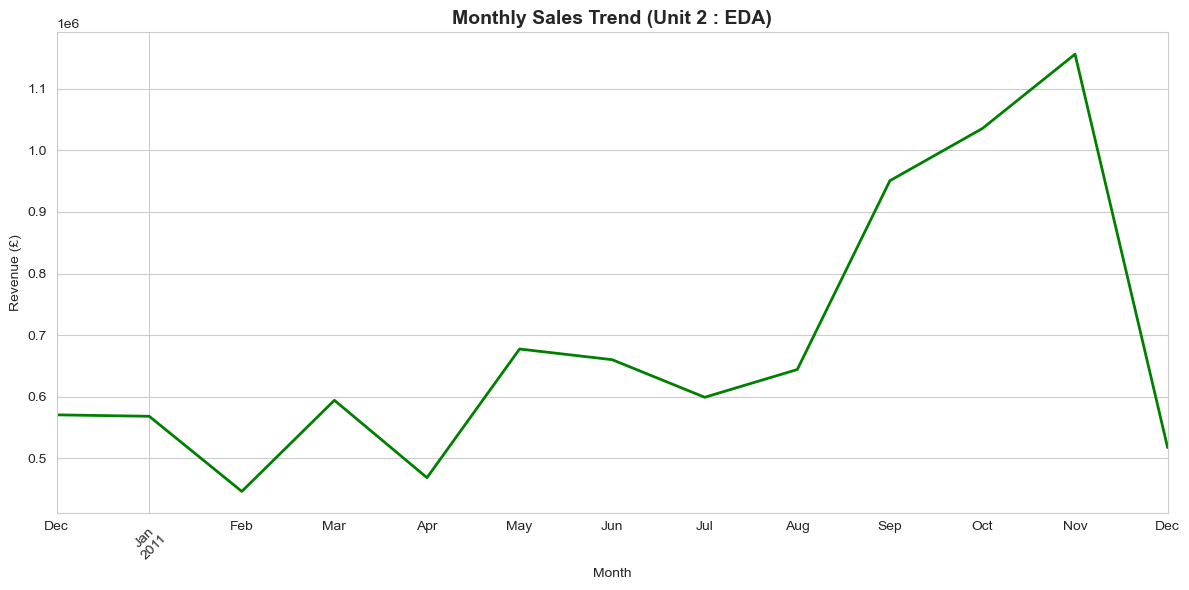

Monthly sales trend plotted!


In [4]:
# Sales over time
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
monthly_sales=df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line',linewidth=2,color='green')
plt.title('Monthly Sales Trend (Unit 2 : EDA)',fontsize=14,fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Monthly sales trend plotted!")

 Top Products


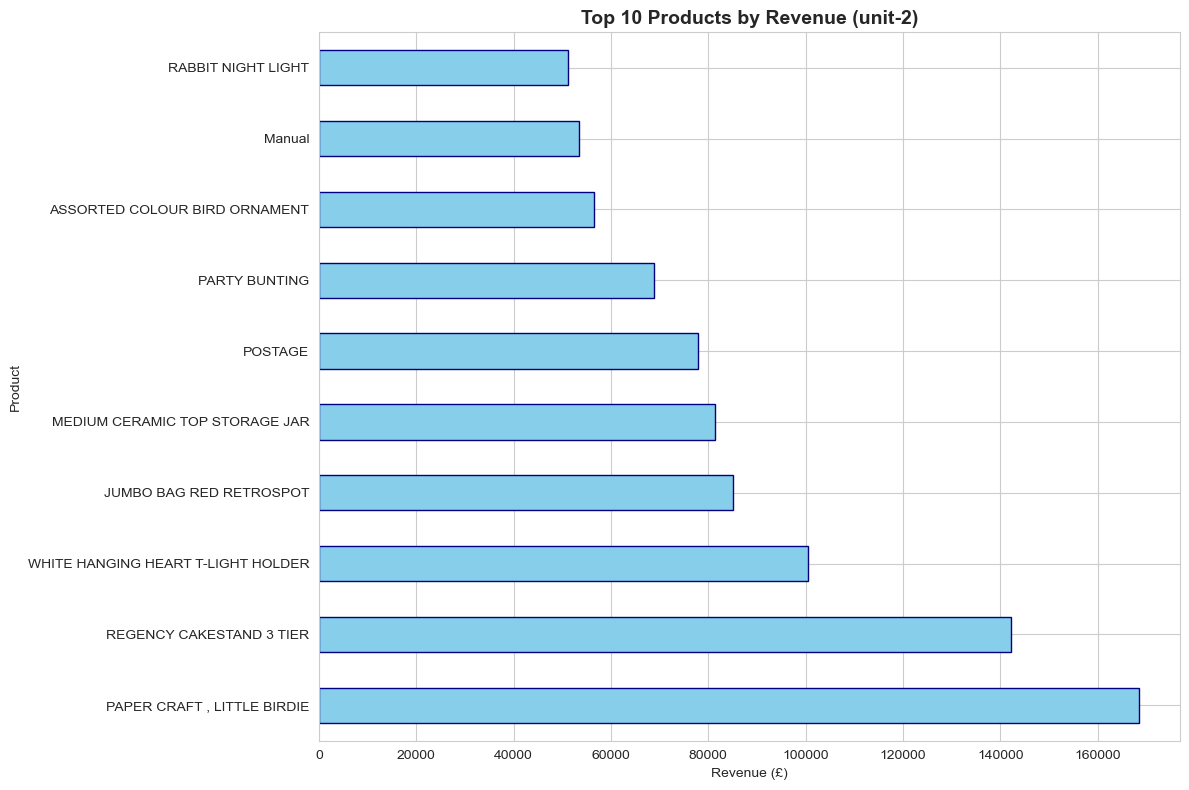

Top products chart!
Top Products: PAPER CRAFT , LITTLE BIRDIE


In [5]:
top_products=df.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,8))
top_products.plot(kind='barh', color='skyblue',edgecolor='navy')
plt.title('Top 10 Products by Revenue (unit-2)', fontsize=14,fontweight='bold')
plt.xlabel('Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()
print("Top products chart!")
print("Top Products:",top_products.index[0])


Top Customers

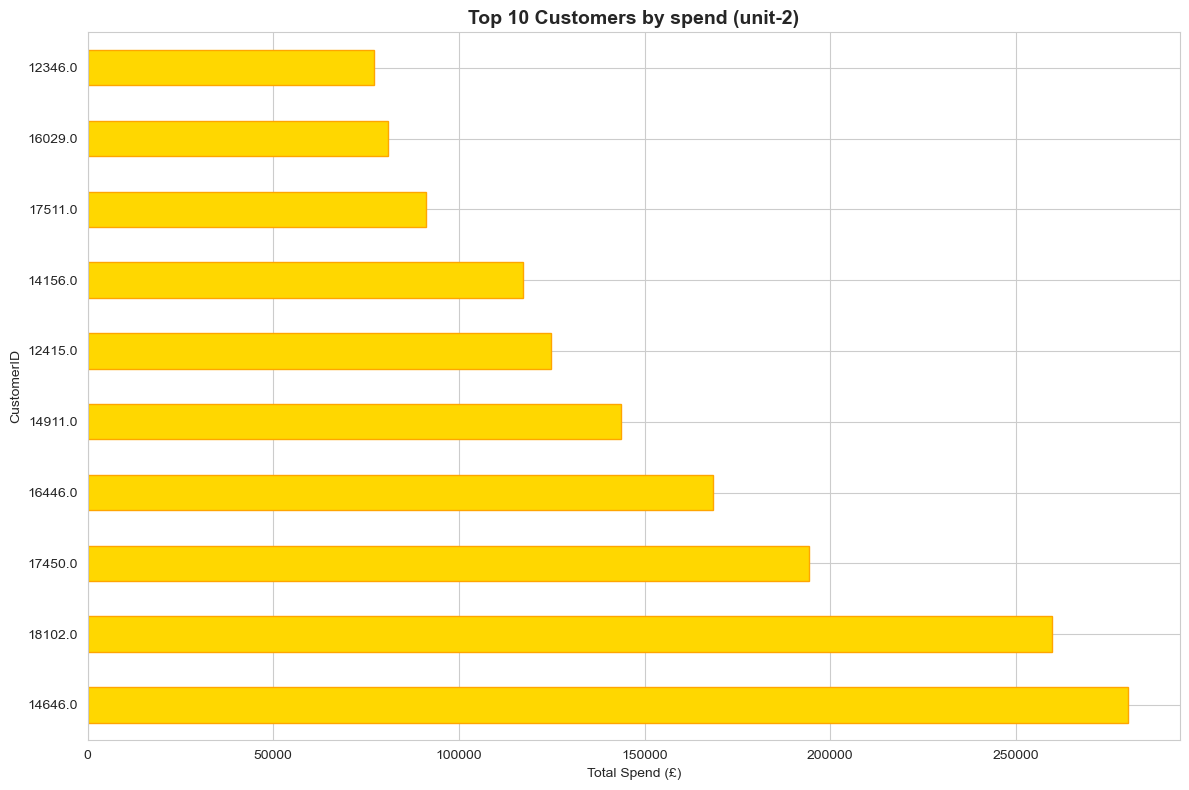

Top Customers chart!
Top Customers spent: £280,206


In [6]:
top_customers=df.groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
top_customers.index=top_customers.index.astype(str)
plt.figure(figsize=(12,8))
top_customers.plot(kind='barh',color='gold', edgecolor='orange')
plt.title("Top 10 Customers by spend (unit-2)",fontsize=14,fontweight='bold')
plt.xlabel('Total Spend (£)')
plt.ylabel('CustomerID')
plt.tight_layout()
plt.show()
print("Top Customers chart!")
print("Top Customers spent:", f"£{top_customers.iloc[0]:,.0f}")

Revenue by Country

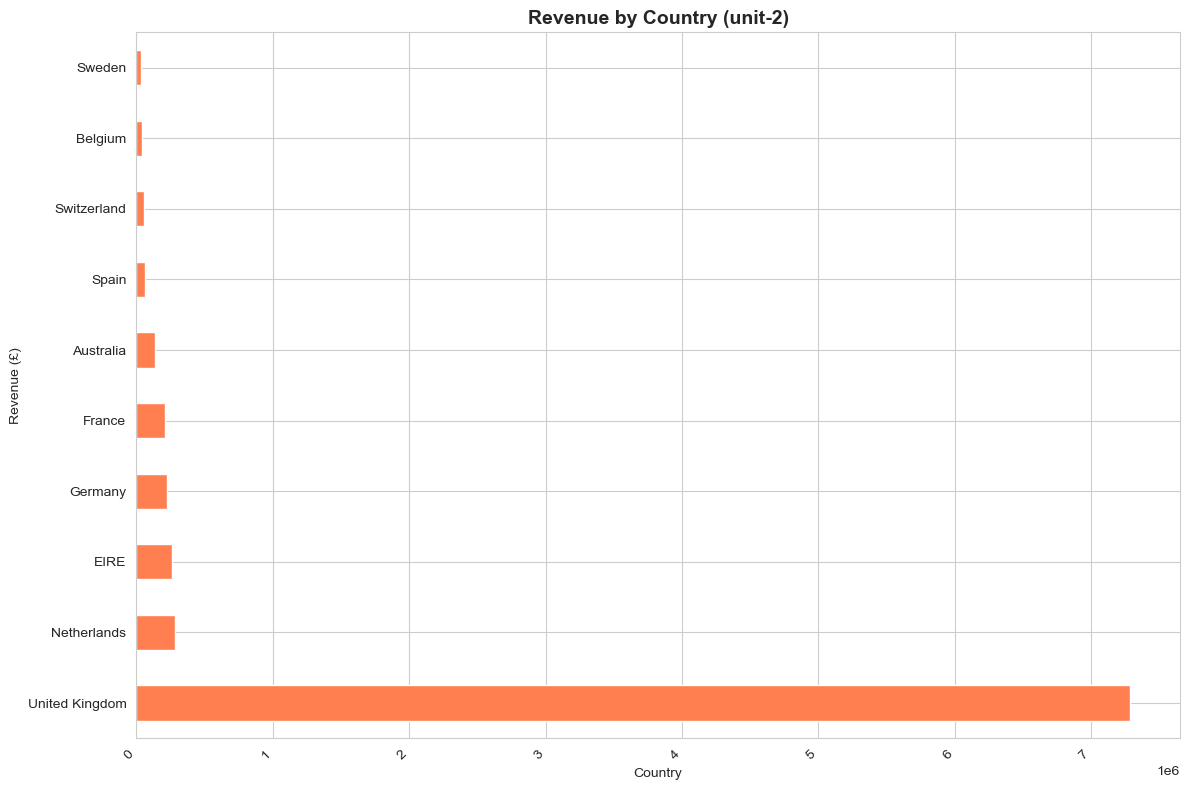

UK Dominates: £7,285,025(84.6%)
Total countries: 10


In [7]:
country_revenue=df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,8))
country_revenue.plot(kind='barh',color='coral')
plt.title("Revenue by Country (unit-2)", fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()
print(f"UK Dominates: £{country_revenue.iloc[0]:,.0f}({country_revenue.iloc[0]/country_revenue.sum()*100:.1f}%)")
print("Total countries:",len(country_revenue))


Sales by Hour (BUSINESS INSIGHT!)

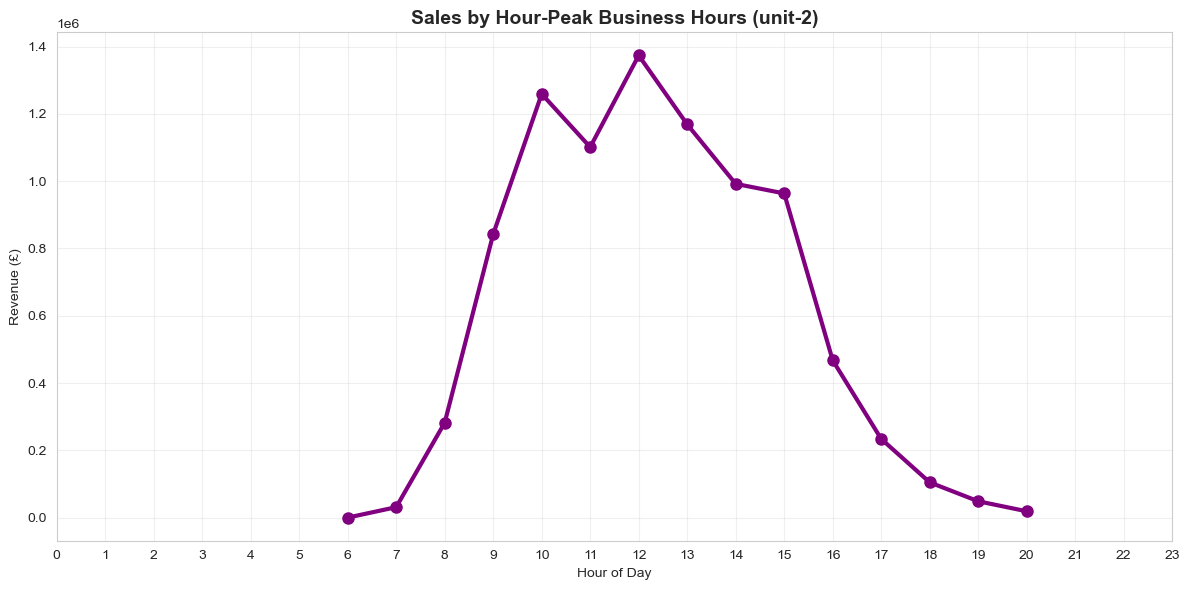

Peak sales hours: [12, 10, 13]
Best hour revenue: £1,373,695


In [8]:
hourly_sales=df.groupby('InvoiceHour')['TotalAmount'].sum()
plt.figure(figsize=(12,6))
plt.plot(hourly_sales.index,hourly_sales.values,marker='o',linewidth=3,markersize=8,color='purple')
plt.title('Sales by Hour-Peak Business Hours (unit-2)',fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (£)')
plt.xticks(range(0,24))
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()
print("Peak sales hours:",hourly_sales.nlargest(3).index.tolist())
print("Best hour revenue:",f"£{hourly_sales.max():,.0f}")


Sales by Day of Week

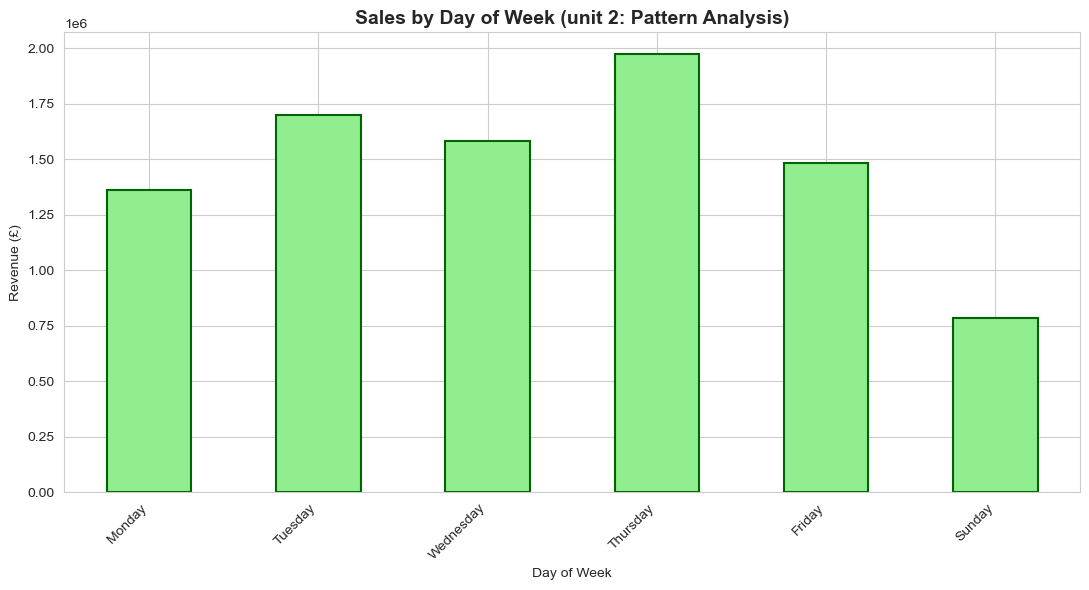

Busiest days: ['Thursday', 'Tuesday', 'Wednesday']


In [9]:
day_names=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_sales=df.groupby('DayOfWeek')['TotalAmount'].sum()
weekly_sales.index=[day_names[i] for i in weekly_sales.index] # here we changed the index by day_names of the weekly_sales data

plt.figure(figsize=(11,6))
weekly_sales.plot(kind='bar',color='lightgreen',edgecolor='darkgreen',linewidth=1.5)
plt.title("Sales by Day of Week (unit 2: Pattern Analysis)", fontsize=14,fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("Busiest days:",weekly_sales.nlargest(3).index.tolist())


Product Category Analysis

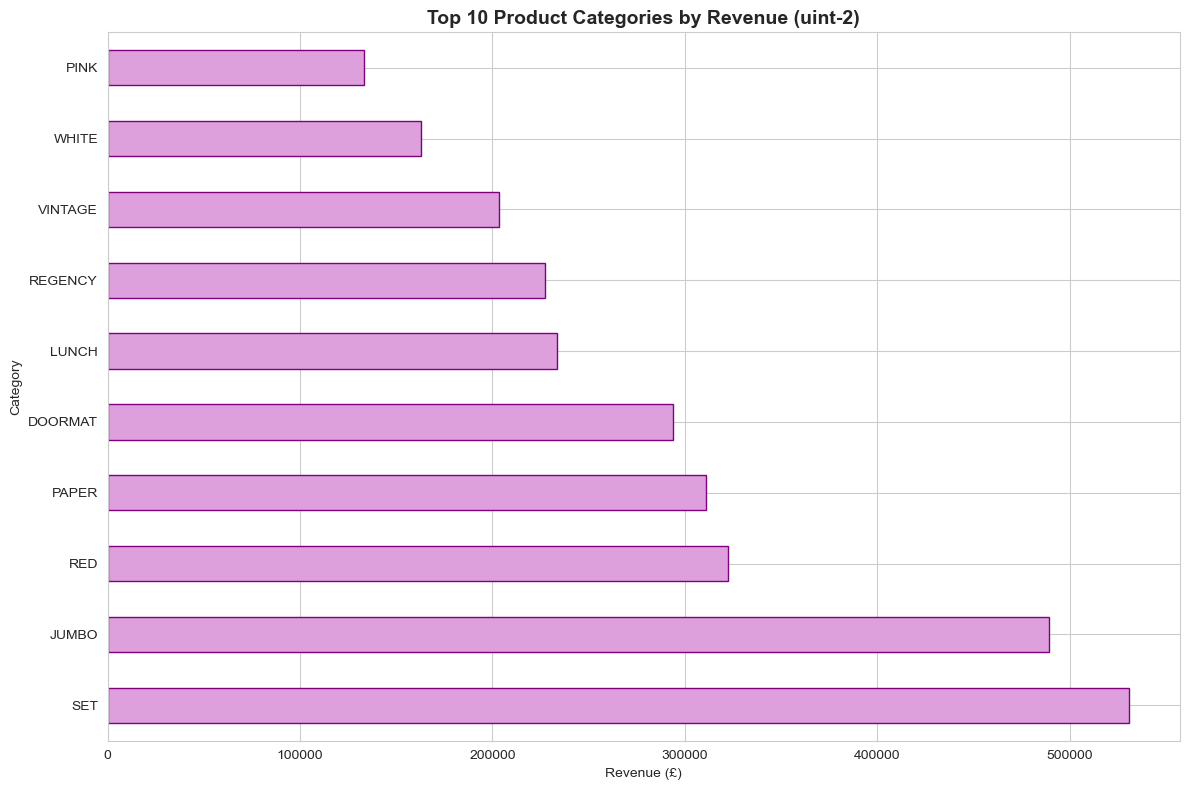

Top categories: ['SET', 'JUMBO', 'RED', 'PAPER', 'DOORMAT', 'LUNCH', 'REGENCY', 'VINTAGE', 'WHITE', 'PINK']
Top category revenue: £530,800


In [10]:
df['Category']=df['Description'].str.split().str[0]
category_sales=df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,8))
category_sales.plot(kind='barh',color='plum', edgecolor='purple')
plt.title('Top 10 Product Categories by Revenue (uint-2)',fontsize=14,fontweight='bold')
plt.xlabel('Revenue (£)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()
print("Top categories:", category_sales.index.tolist())
print("Top category revenue:", f"£{category_sales.iloc[0]:,.0f}")

Correlation Heatmap variable relationships analysis

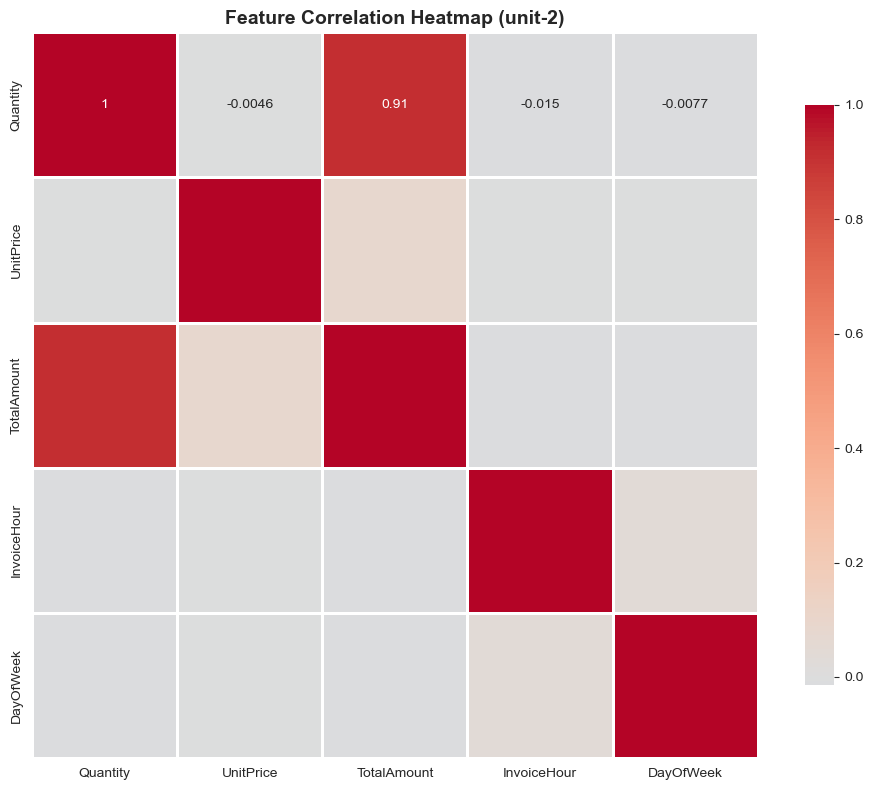

Correlation analysis complete!
Key insight: TotalAmount perfectly correlates with Quantity X UnitPrice


In [11]:
numeric_cols=['Quantity','UnitPrice','TotalAmount','InvoiceHour','DayOfWeek']
corr_matrix=df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm', center=0,square=True, linewidths=1, cbar_kws={"shrink": .8})

plt.title("Feature Correlation Heatmap (unit-2)", fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()
print("Correlation analysis complete!")
print("Key insight: TotalAmount perfectly correlates with Quantity X UnitPrice")


Plotly Interactive Dashboard

In [12]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig1=px.line(df.groupby('InvoiceMonth')['TotalAmount'].sum().reset_index(), x='InvoiceMonth',y='TotalAmount', title='Interactive Montly Sales Trend', labels={'TotalAmount': 'Revenue (£)', 'InvoiceMonth':'Month'})

hourly_heatmap=df.groupby(['InvoiceHour','DayOfWeek'])['TotalAmount'].sum().unstack(fill_value=0)
fig2=px.imshow(hourly_heatmap,title='Hourly Sales Heat map(Interactive)', labels=dict(x="Day of Week", y = "Hour", color="Revenue (£)"), aspect="auto",color_continuous_scale='Viridis')

fig1.show()
fig2.show()


Top Products Interactive Bar Chart (Unit II)

In [22]:
top_products=df.groupby("Description")["TotalAmount"].sum().sort_values(ascending=False).head(15)
fig3=px.bar(top_products.reset_index(), x="TotalAmount", y="Description", title='Top Products by Revenue',labels={'TotalAmount':'Revenue', 'Description':'Product'}, orientation='h',color='TotalAmount', color_continuous_scale='Plasma')
fig3.update_layout(height=600, showlegend=False)
fig3.show()
print(f"Top seller: {top_products.index[0]} (£{top_products.iloc[0]:,.0f})")

Top seller: PAPER CRAFT , LITTLE BIRDIE (£168,470)


Final EDA Summary (for practical / report)

In [39]:
print("=== E-commerce EDA Project – Final Summary ===")
print("Dataset: Online Retail (E-commerce transactions)")
print("Total rows:", len(df))
print("Unique customers:", df['CustomerID'].nunique())
print("Unique products:",df['Description'].nunique())
print("Total Countries:", df['Country'].nunique())
print(f"Total Revenue: £{df['TotalAmount'].sum():,.2f}")
print(f"Average Revenue per Invoice: £{df['TotalAmount'].mean():,.2f}")
print("\nKey Business Insights:")
monthly_sales = df.groupby('InvoiceMonth')['TotalAmount'].sum()
print("- Month with highest sales:", monthly_sales.idxmax())
country_sales = df.groupby('Country')['TotalAmount'].sum()
print("- Country with highest revenue:", country_sales.idxmax())
product_sales = df.groupby('Description')['TotalAmount'].sum()
print("- Top selling product:", product_sales.idxmax())
print("\nVisualizations completed:")
print("• Monthly sales trend (Line)")
print("• Top products, top customers, top countries (Bar/Heatmap)")
print("• Hourly and weekly patterns (Bar/Heatmap)")
print("• Category distribution (Pie/Bar)")
print("• Correlation heatmap (Quantity, UnitPrice, TotalAmount, etc.)")
print("• Interactive Plotly dashboard (Monthly trend + Hourly heatmap)")

=== E-commerce EDA Project – Final Summary ===
Dataset: Online Retail (E-commerce transactions)
Total rows: 392692
Unique customers: 4338
Unique products: 3877
Total Countries: 37
Total Revenue: £8,887,208.89
Average Revenue per Invoice: £22.63

Key Business Insights:
- Month with highest sales: 11
- Country with highest revenue: United Kingdom
- Top selling product: PAPER CRAFT , LITTLE BIRDIE

Visualizations completed:
• Monthly sales trend (Line)
• Top products, top customers, top countries (Bar/Heatmap)
• Hourly and weekly patterns (Bar/Heatmap)
• Category distribution (Pie/Bar)
• Correlation heatmap (Quantity, UnitPrice, TotalAmount, etc.)
• Interactive Plotly dashboard (Monthly trend + Hourly heatmap)
